In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Importing libraries


In [2]:
!pip install seaborn scikit-learn -q

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
train_path="/content/drive/MyDrive/fruit_recognisation/train"
val_path="/content/drive/MyDrive/fruit_recognisation/validation"

Data preprocessing

## training image preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
   # '/content/drive/MyDrive/fruit_recognisation/train',
    labels="inferred",
    label_mode="categorical",
   # class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,

)

Found 2943 files belonging to 36 classes.


## validation image preprocessing

In [5]:
validation_set=tf.keras.utils.image_dataset_from_directory(
   # '/content/drive/MyDrive/fruit_recognisation/validation',
   val_path,
    labels="inferred",
    label_mode="categorical",
   # class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=False,

)
class_names = training_set.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Total classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
training_set = training_set.prefetch(AUTOTUNE)
validation_set = validation_set.prefetch(AUTOTUNE)


Found 288 files belonging to 36 classes.
Class names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Total classes: 36


Data augmentation


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])


Model bulding

In [7]:
cnn = tf.keras.models.Sequential()

## Building convolution layer

In [8]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Input(shape=(64, 64, 3)))

cnn.add(data_augmentation)

cnn.add(tf.keras.layers.Rescaling(1./255))

cnn.add(tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(128, kernel_size=3, activation="relu"))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(256, activation="relu"))
cnn.add(tf.keras.layers.Dropout(0.3))

cnn.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,404 (4.89 MB)

 Trainable params: 1,282,404 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

normal training

Confusion matrix function

In [15]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history1 = cnn.fit(
    training_set,
    validation_data=validation_set,
    epochs=30
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 836ms/step - accuracy: 0.4404 - loss: 1.8157 - val_accuracy: 0.6181 - val_loss: 1.2727
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 866ms/step - accuracy: 0.4597 - loss: 1.7702 - val_accuracy: 0.6007 - val_loss: 1.3298
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 78s 842ms/step - accuracy: 0.4645 - loss: 1.7587 - val_accuracy: 0.6701 - val_loss: 1.1939
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 874ms/step - accuracy: 0.4604 - loss: 1.7716 - val_accuracy: 0.5799 - val_loss: 1.3132
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 826ms/step - accuracy: 0.4618 - loss: 1.7501 - val_accuracy: 0.6424 - val_loss: 1.2132
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 908ms/step - accuracy: 0.4798 - loss: 1.7168 - val_accuracy: 0.5903 - val_loss: 1.2826
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 842ms/step - accuracy: 0.4638 - loss: 1.7335 - val_accuracy: 0.6458 - val_loss: 1.1888
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 839ms/step - accuracy: 0.4621 - loss: 1.7214 - val_accu

In [16]:
def get_true_and_pred(dataset, model):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)

        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))

    return np.array(y_true), np.array(y_pred)


Confusion matrix before fine-tuning

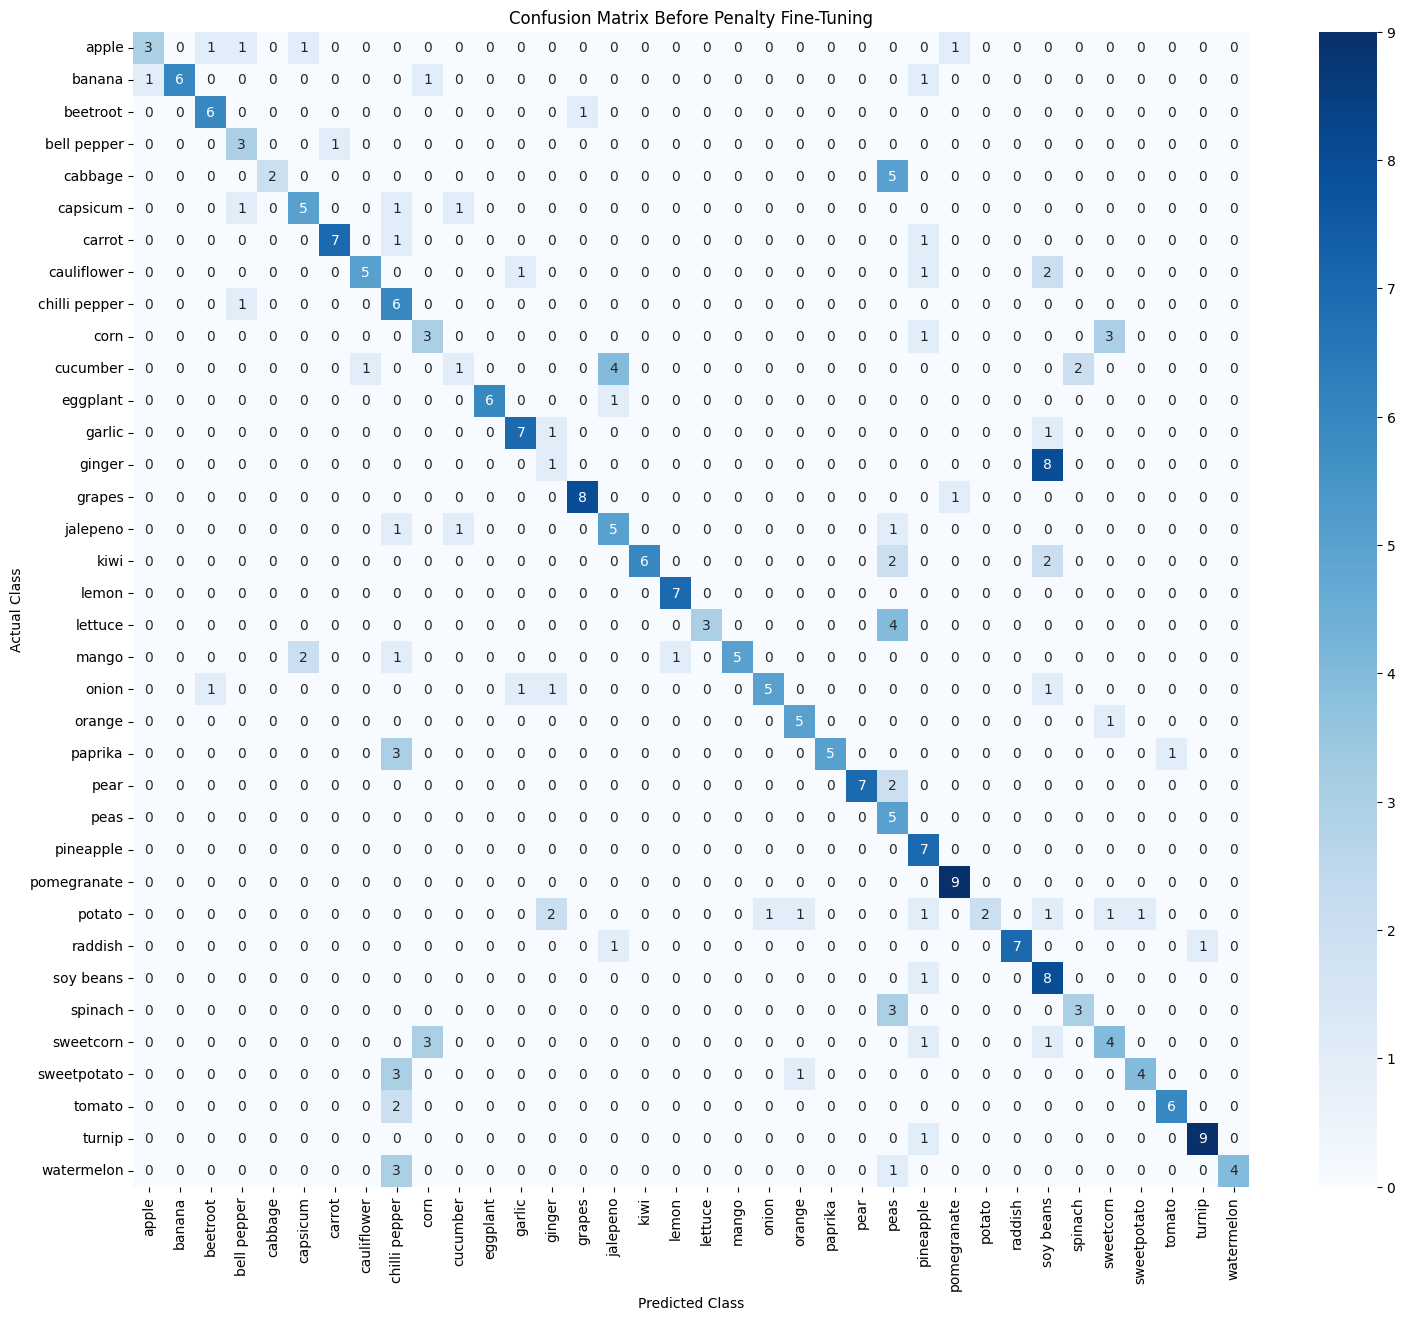

Classification Report Before Fine-Tuning:
               precision    recall  f1-score   support

        apple       0.75      0.43      0.55         7
       banana       1.00      0.67      0.80         9
     beetroot       0.75      0.86      0.80         7
  bell pepper       0.50      0.75      0.60         4
      cabbage       1.00      0.29      0.44         7
     capsicum       0.62      0.62      0.62         8
       carrot       0.88      0.78      0.82         9
  cauliflower       0.83      0.56      0.67         9
chilli pepper       0.29      0.86      0.43         7
         corn       0.43      0.43      0.43         7
     cucumber       0.33      0.12      0.18         8
     eggplant       1.00      0.86      0.92         7
       garlic       0.78      0.78      0.78         9
       ginger       0.20      0.11      0.14         9
       grapes       0.89      0.89      0.89         9
     jalepeno       0.45      0.62      0.53         8
         kiwi       1.

In [17]:

y_true, y_pred = get_true_and_pred(validation_set, cnn)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix Before Penalty Fine-Tuning")
plt.show()

print("Classification Report Before Fine-Tuning:")
print(classification_report(y_true, y_pred, target_names=class_names))

Create penalty matrix

In [18]:

penalty_matrix_np = np.ones((num_classes, num_classes), dtype=np.float32)

for i in range(num_classes):
    row_sum = np.sum(cm[i])

    for j in range(num_classes):
        if i == j:
            penalty_matrix_np[i][j] = 1.0
        else:
            penalty_matrix_np[i][j] = 1.0 + (cm[i][j] / (row_sum + 1))

penalty_matrix = tf.constant(penalty_matrix_np, dtype=tf.float32)

print("Penalty Matrix:")
print(penalty_matrix_np)

Penalty Matrix:
[[1.    1.    1.125 ... 1.    1.    1.   ]
 [1.1   1.    1.    ... 1.    1.    1.   ]
 [1.    1.    1.    ... 1.    1.    1.   ]
 ...
 [1.    1.    1.    ... 1.    1.    1.   ]
 [1.    1.    1.    ... 1.    1.    1.   ]
 [1.    1.    1.    ... 1.    1.    1.   ]]


Custom penalty loss

In [19]:

def penalty_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

    true_class = tf.argmax(y_true, axis=1)
    pred_class = tf.argmax(y_pred, axis=1)

    indices = tf.stack([true_class, pred_class], axis=1)

    penalties = tf.gather_nd(penalty_matrix, indices)

    normal_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    final_loss = normal_loss * penalties

    return final_loss

Fine-tuning with custom loss

In [21]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss=penalty_categorical_crossentropy,
    metrics=["accuracy"]
)

history2 = cnn.fit(
    training_set,
    validation_data=validation_set,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 89s 936ms/step - accuracy: 0.5919 - loss: 1.3782 - val_accuracy: 0.6562 - val_loss: 1.3112
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 856ms/step - accuracy: 0.5797 - loss: 1.4037 - val_accuracy: 0.6562 - val_loss: 1.3472
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 821ms/step - accuracy: 0.5708 - loss: 1.4164 - val_accuracy: 0.6632 - val_loss: 1.2871
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 838ms/step - accuracy: 0.5712 - loss: 1.3874 - val_accuracy: 0.6632 - val_loss: 1.3239
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 78s 848ms/step - accuracy: 0.5855 - loss: 1.3665 - val_accuracy: 0.6528 - val_loss: 1.3215
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 78s 846ms/step - accuracy: 0.5797 - loss: 1.3698 - val_accuracy: 0.6806 - val_loss: 1.2543
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 823ms/step - accuracy: 0.5889 - loss: 1.3746 - val_accuracy: 0.6597 - val_loss: 1.3485
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 839ms/step - accuracy: 0.5759 - loss: 1.3878 - val_accu

Final confusion matrix

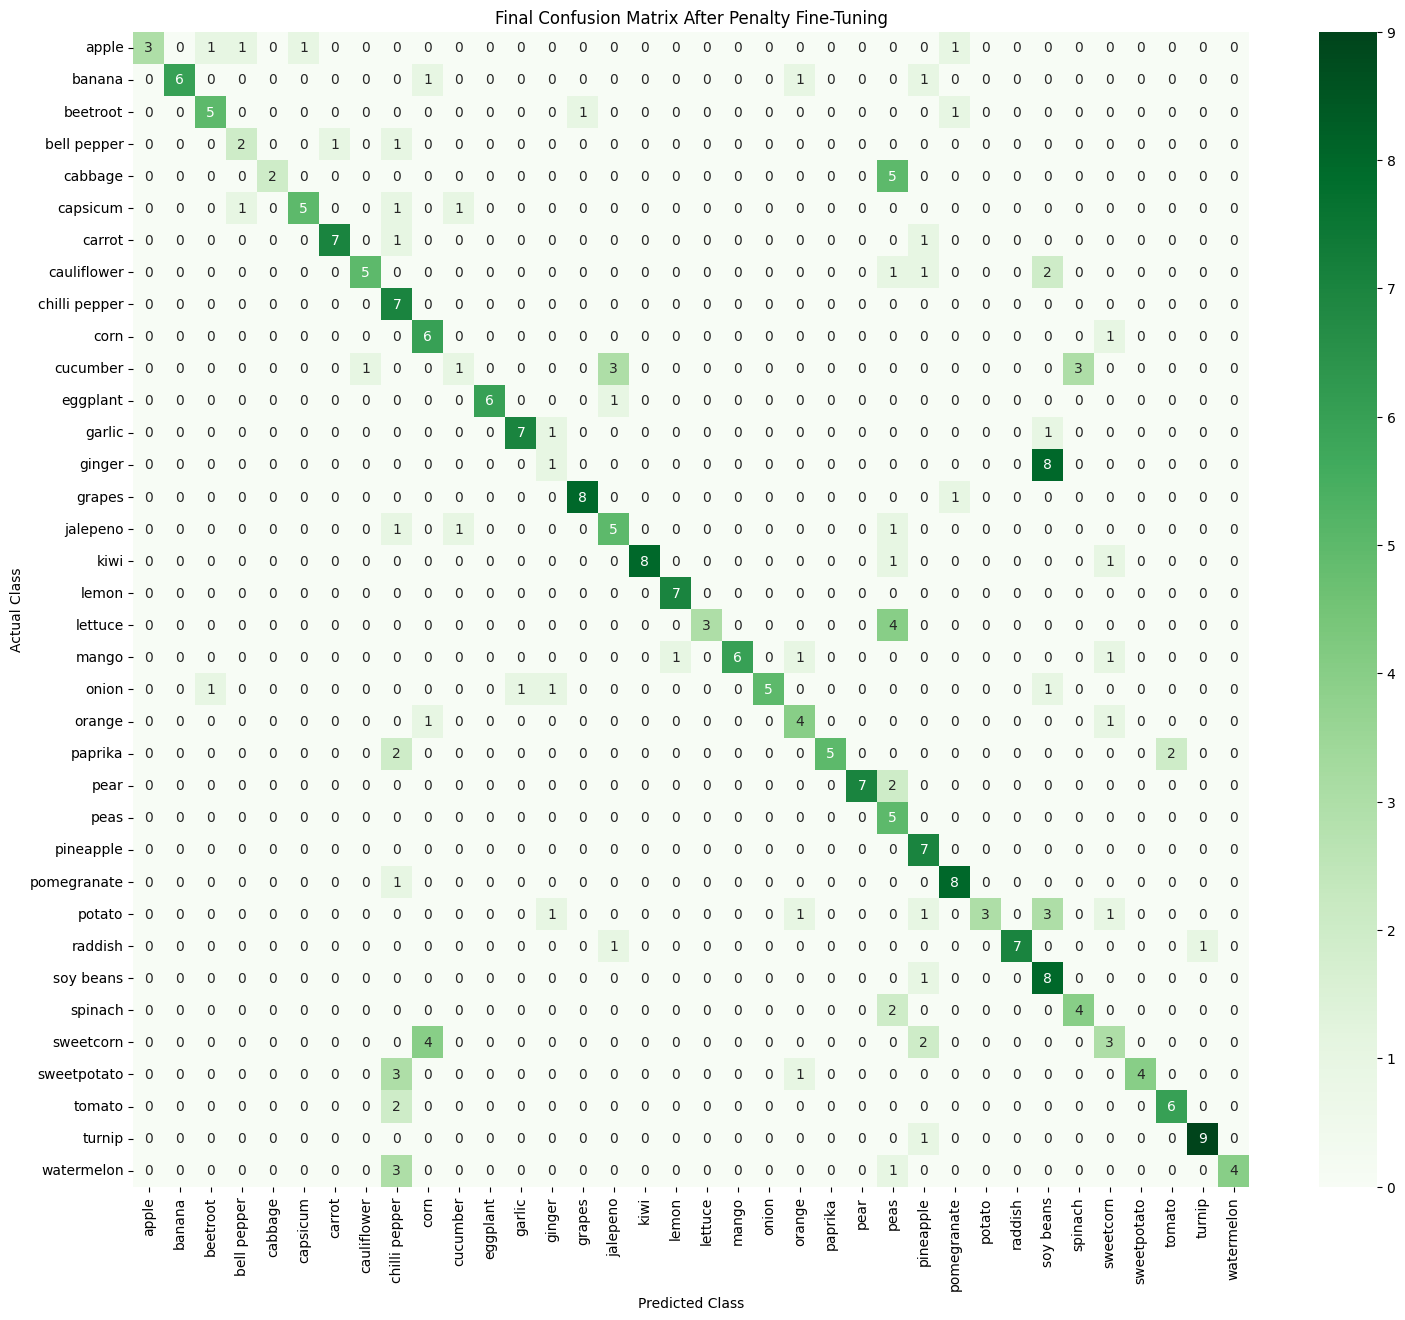

Classification Report After Fine-Tuning:
               precision    recall  f1-score   support

        apple       1.00      0.43      0.60         7
       banana       1.00      0.67      0.80         9
     beetroot       0.71      0.71      0.71         7
  bell pepper       0.50      0.50      0.50         4
      cabbage       1.00      0.29      0.44         7
     capsicum       0.83      0.62      0.71         8
       carrot       0.88      0.78      0.82         9
  cauliflower       0.83      0.56      0.67         9
chilli pepper       0.32      1.00      0.48         7
         corn       0.50      0.86      0.63         7
     cucumber       0.33      0.12      0.18         8
     eggplant       1.00      0.86      0.92         7
       garlic       0.88      0.78      0.82         9
       ginger       0.25      0.11      0.15         9
       grapes       0.89      0.89      0.89         9
     jalepeno       0.50      0.62      0.56         8
         kiwi       1.0

In [22]:
final_y_true, final_y_pred = get_true_and_pred(validation_set, cnn)

final_cm = confusion_matrix(final_y_true, final_y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final Confusion Matrix After Penalty Fine-Tuning")
plt.show()

print("Classification Report After Fine-Tuning:")
print(classification_report(final_y_true, final_y_pred, target_names=class_names))

Accuracy and loss graph

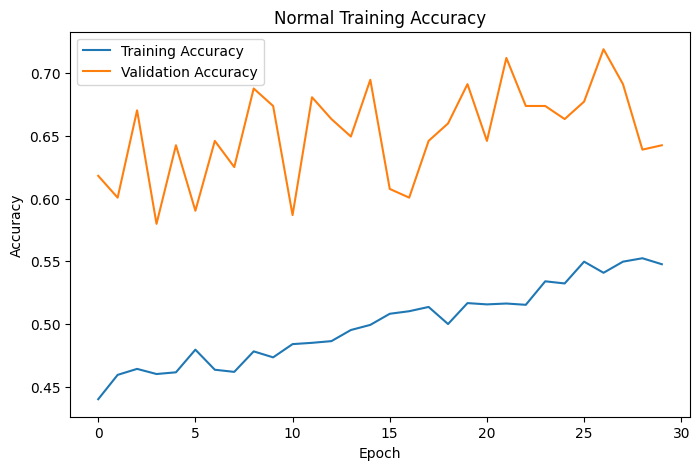

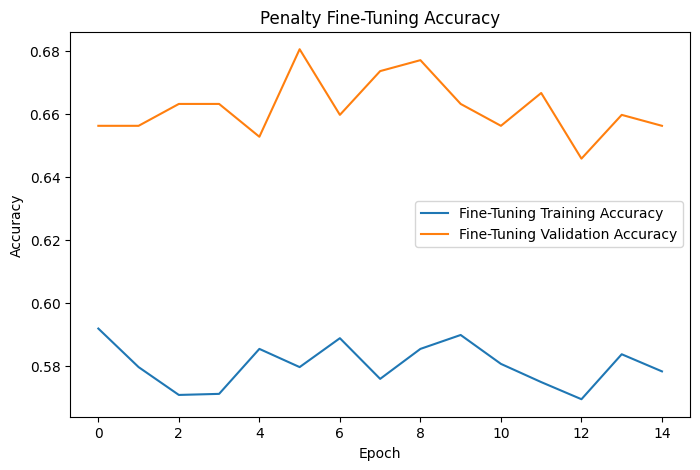

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history1.history["accuracy"], label="Training Accuracy")
plt.plot(history1.history["val_accuracy"], label="Validation Accuracy")
plt.title("Normal Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history2.history["accuracy"], label="Fine-Tuning Training Accuracy")
plt.plot(history2.history["val_accuracy"], label="Fine-Tuning Validation Accuracy")
plt.title("Penalty Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Saving model and history

In [24]:

cnn.save("fruit_vegetable_penalty_model.h5")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

with open("normal_training_history.json", "w") as f:
    json.dump(history1.history, f)

with open("fine_tuning_history.json", "w") as f:
    json.dump(history2.history, f)

print("Model and files saved successfully.")

Model and files saved successfully.
